In [2]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
sovitrath_diabetic_retinopathy_224x224_gaussian_filtered_path = kagglehub.dataset_download('sovitrath/diabetic-retinopathy-224x224-gaussian-filtered')

print('Data source import complete.')
print(sovitrath_diabetic_retinopathy_224x224_gaussian_filtered_path)

Data source import complete.
/kaggle/input/diabetic-retinopathy-224x224-gaussian-filtered


In [3]:
import os
import shutil

# Répertoires
source_dir = '/kaggle/input/diabetic-retinopathy-224x224-gaussian-filtered/gaussian_filtered_images/gaussian_filtered_images'
target_dir = '/content/images'

# Dictionnaire de renommage
rename_dict = {
    'Mild': '1_Mild',
    'Moderate': '2_Moderate',
    'No_DR': '0_No_DR',
    'Proliferate_DR': '4_Proliferate_DR',
    'Severe': '3_Severe'
}

# Créer le dossier cible
os.makedirs(target_dir, exist_ok=True)

# Copier et renommer les dossiers
for old_name, new_name in rename_dict.items():
    old_path = os.path.join(source_dir, old_name)
    new_path = os.path.join(target_dir, new_name)

    if os.path.exists(old_path):
        shutil.copytree(old_path, new_path)
        print(f'Copié et renommé : {old_name} → {new_name}')
    else:
        print(f'Dossier introuvable : {old_path}')


Copié et renommé : Mild → 1_Mild
Copié et renommé : Moderate → 2_Moderate
Copié et renommé : No_DR → 0_No_DR
Copié et renommé : Proliferate_DR → 4_Proliferate_DR
Copié et renommé : Severe → 3_Severe


In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import pandas as pd
import random, os
import shutil
import matplotlib.pyplot as plt
from matplotlib.image import imread
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.metrics import categorical_accuracy
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv(r'/kaggle/input/diabetic-retinopathy-224x224-gaussian-filtered/train.csv')

diagnosis_dict_binary = {
    0: 'No_DR',
    1: 'DR',
    2: 'DR',
    3: 'DR',
    4: 'DR'
}

diagnosis_dict = {
    0: '0_No_DR',
    1: '1_Mild',
    2: '2_Moderate',
    3: '3_Severe',
    4: '4_Proliferate_DR',
}

path = '/content/images'
df['binary_type'] =  df['diagnosis'].map(diagnosis_dict_binary.get)
df['type'] = df['diagnosis'].map(diagnosis_dict.get)
df['filename'] = path + '/' + df['type'] + '/' + df['id_code'] + '.png'
df.head()

,id_code,diagnosis,binary_type,type,filename
0,000c1434d8d7,2,DR,2_Moderate,/content/images/2_Moderate/000c1434d8d7.png
1,001639a390f0,4,DR,4_Proliferate_DR,/content/images/4_Proliferate_DR/001639a390f0.png
2,0024cdab0c1e,1,DR,1_Mild,/content/images/1_Mild/0024cdab0c1e.png
3,002c21358ce6,0,No_DR,0_No_DR,/content/images/0_No_DR/002c21358ce6.png
4,005b95c28852,0,No_DR,0_No_DR,/content/images/0_No_DR/005b95c28852.png


<Axes: ylabel='type'>

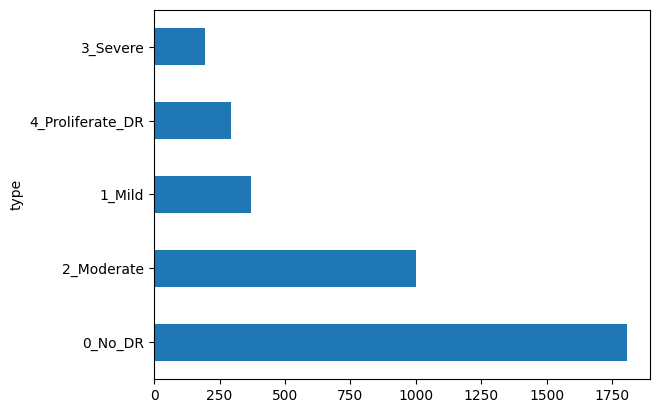

In [6]:
df['type'].value_counts().plot(kind='barh')

<Axes: ylabel='binary_type'>

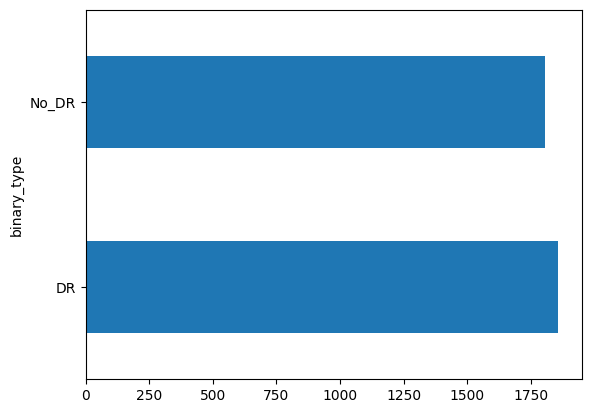

In [7]:
df['binary_type'].value_counts().plot(kind='barh')

In [8]:
train_intermediate, test = train_test_split(df, test_size = 0.15, stratify = df['type'])
train, val = train_test_split(train_intermediate, test_size = 0.15 / (1 - 0.15), stratify = train_intermediate['type'])

print("Train shape: ", train.shape)
print("Test shape: ",test.shape)
print("Valid shape: ", val.shape)

print(train['type'].value_counts(), '\n')
print(test['type'].value_counts(), '\n')
print(val['type'].value_counts(), '\n')

Train shape:  (2562, 5)
Test shape:  (550, 5)
Valid shape:  (550, 5)
type
0_No_DR             1263
2_Moderate           699
1_Mild               258
4_Proliferate_DR     207
3_Severe             135
Name: count, dtype: int64 

type
0_No_DR             271
2_Moderate          150
1_Mild               56
4_Proliferate_DR     44
3_Severe             29
Name: count, dtype: int64 

type
0_No_DR             271
2_Moderate          150
1_Mild               56
4_Proliferate_DR     44
3_Severe             29
Name: count, dtype: int64 



In [9]:
train_path1 = '/content/images'

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_batches = train_datagen.flow_from_dataframe(
    dataframe=train,
    directory=train_path1,
    x_col='filename',
    y_col='type',
    target_size=(224, 224),
    class_mode='categorical',
    shuffle=True,
    batch_size=32
)

val_batches = val_datagen.flow_from_dataframe(
    dataframe=val,
    directory=train_path1,
    x_col='filename',
    y_col='type',
    target_size=(224, 224),
    class_mode='categorical',
    shuffle=True,
    batch_size=32)

test_batches = test_datagen.flow_from_dataframe(
    dataframe=test,
    directory=train_path1,
    x_col='filename',
    y_col='type',
    target_size=(224, 224),
    class_mode='categorical',
    shuffle=False,
    batch_size=32)

Found 2562 validated image filenames belonging to 5 classes.
Found 550 validated image filenames belonging to 5 classes.
Found 550 validated image filenames belonging to 5 classes.


In [10]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Flatten
from tensorflow.keras.optimizers import Adam

densenet = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

model = tf.keras.Sequential()
model.add(densenet)
model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dropout(0.5))
model.add(layers.Dense(5, activation='sigmoid'))

model.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(),
    optimizer=Adam(0.0001,decay=1e-6),
    metrics=['accuracy']
)

model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         5,125 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,042,629 (26.87 MB)

 Trainable params: 6,958,981 (26.55 MB)

 Non-trainable params: 83,648 (326.75 KB)

In [11]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Callbacks
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(train_batches,
                    epochs=50,
                    validation_data=val_batches,
                    callbacks=[reduce_lr, early_stop]
                    )

Epoch 1/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 299s 2s/step - accuracy: 0.6013 - loss: 1.1818 - val_accuracy: 0.5509 - val_loss: 1.1534 - learning_rate: 1.0000e-04
Epoch 2/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 24s 295ms/step - accuracy: 0.7722 - loss: 0.5992 - val_accuracy: 0.7255 - val_loss: 0.7467 - learning_rate: 1.0000e-04
Epoch 3/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 24s 297ms/step - accuracy: 0.8327 - loss: 0.4243 - val_accuracy: 0.7400 - val_loss: 0.9271 - learning_rate: 1.0000e-04
Epoch 4/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 24s 299ms/step - accuracy: 0.8796 - loss: 0.3120 - val_accuracy: 0.7709 - val_loss: 1.1096 - learning_rate: 1.0000e-04
Epoch 5/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 41s 296ms/step - accuracy: 0.9139 - loss: 0.2200 - val_accuracy: 0.8055 - val_loss: 0.9342 - learning_rate: 1.0000e-04
Epoch 6/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 25s 304ms/step - accuracy: 0.9361 - loss: 0.1932 - val_accuracy: 0.8182 - val_loss: 0.7111 - learning_rate: 2.0000e-05
Epoch 7/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 24s 298ms/step - accur

In [ ]:
model.save('DensNet201_model_2.h5')

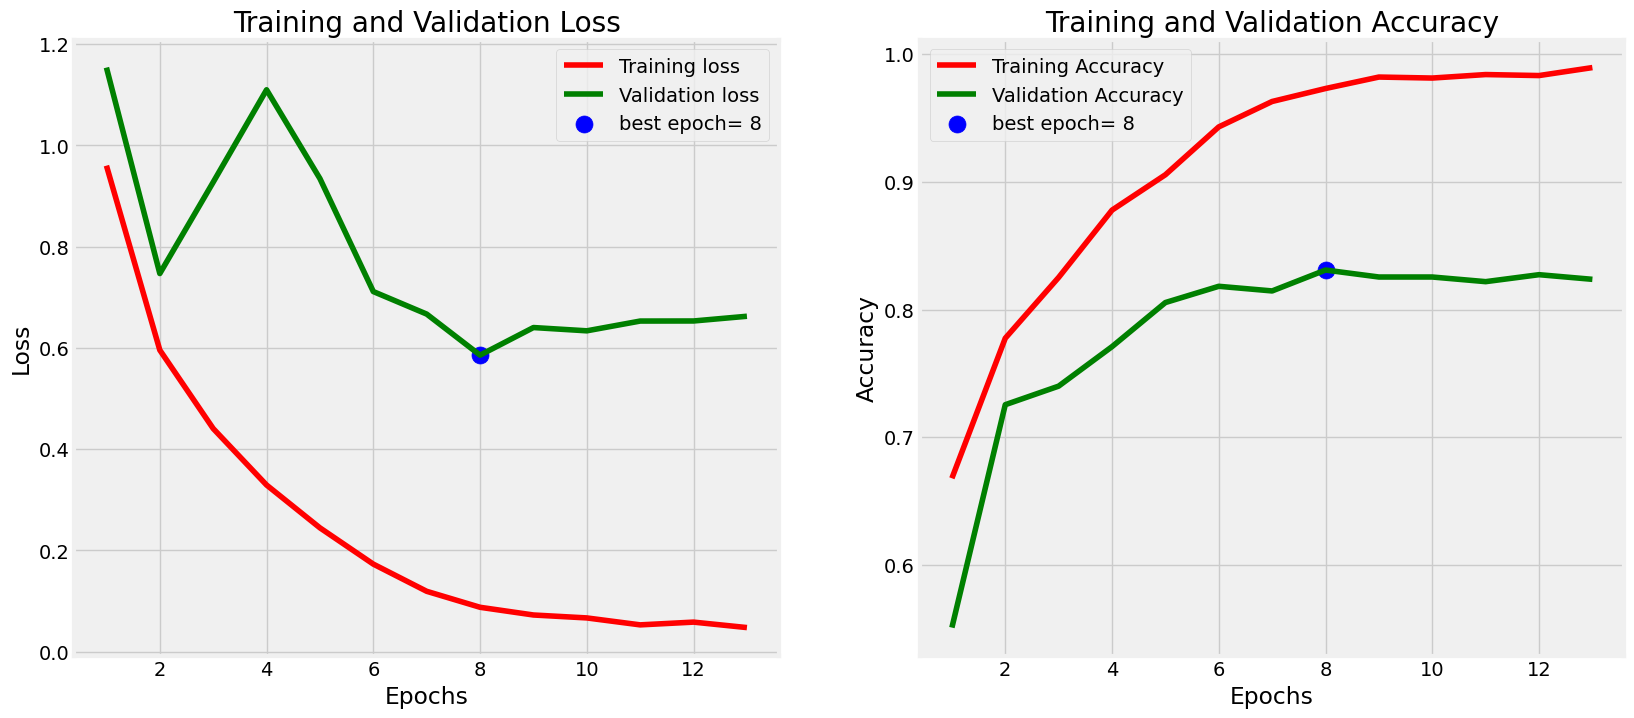

In [13]:
# Define needed variables
tr_acc = history.history['accuracy']
tr_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]
Epochs = [i+1 for i in range(len(tr_acc))]
loss_label = f'best epoch= {str(index_loss + 1)}'
acc_label = f'best epoch= {str(index_acc + 1)}'

# Plot training history
plt.figure(figsize= (20, 8))
plt.style.use('fivethirtyeight')

plt.subplot(1, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label= 'Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label= 'Validation Accuracy')
plt.scatter(index_acc + 1 , acc_highest, s= 150, c= 'blue', label= acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout
plt.show()

In [12]:
train_score = model.evaluate(train_batches, verbose= 1)
valid_score = model.evaluate(val_batches, verbose= 1)
test_score = model.evaluate(test_batches, verbose= 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

81/81 ━━━━━━━━━━━━━━━━━━━━ 15s 179ms/step - accuracy: 0.9929 - loss: 0.0333
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.8331 - loss: 0.5602
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - accuracy: 0.8531 - loss: 0.5820
Train Loss:  0.03287968412041664
Train Accuracy:  0.9929742217063904
--------------------
Validation Loss:  0.5855043530464172
Validation Accuracy:  0.8309090733528137
--------------------
Test Loss:  0.6173725724220276
Test Accuracy:  0.8345454335212708


18/18 ━━━━━━━━━━━━━━━━━━━━ 22s 702ms/step


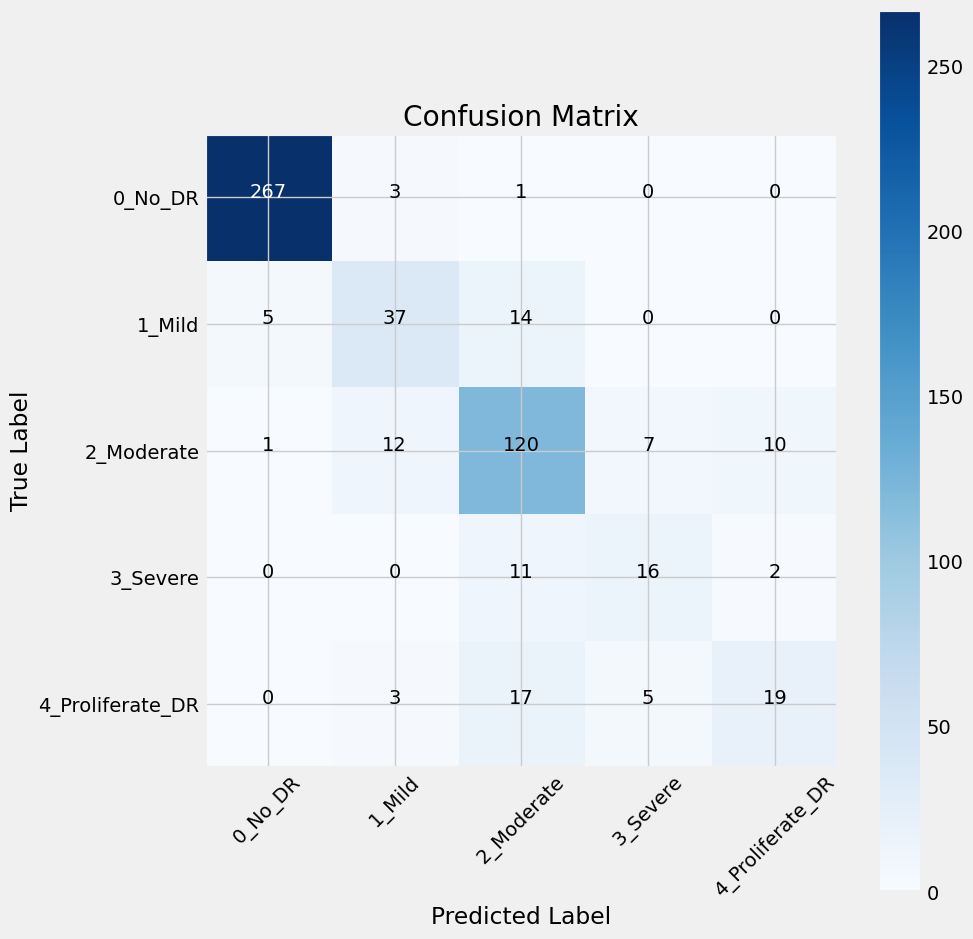

In [14]:
from sklearn.metrics import confusion_matrix, classification_report
import itertools

preds = model.predict(test_batches, steps=len(test_batches))
y_pred = np.argmax(preds, axis=1)

g_dict = test_batches.class_indices
classes = list(g_dict.keys())

# Confusion matrix
cm = confusion_matrix(test_batches.classes, y_pred)

plt.figure(figsize= (10, 10))
plt.imshow(cm, interpolation= 'nearest', cmap= plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation= 45)
plt.yticks(tick_marks, classes)

thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment= 'center', color= 'white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()

In [15]:
# Classification report
print(classification_report(test_batches.classes, y_pred, target_names= classes))

                  precision    recall  f1-score   support

         0_No_DR       0.98      0.99      0.98       271
          1_Mild       0.67      0.66      0.67        56
      2_Moderate       0.74      0.80      0.77       150
        3_Severe       0.57      0.55      0.56        29
4_Proliferate_DR       0.61      0.43      0.51        44

        accuracy                           0.83       550
       macro avg       0.71      0.69      0.70       550
    weighted avg       0.83      0.83      0.83       550

